# Data Validation Report
**Dataset:** `data/processed/flights_weather.csv`  
**Sources:** BTS 2015 Flight Delays + Open-Meteo Historical Weather API  


In [1]:
import os
from pathlib import Path

import pandas as pd

# Always run from project root regardless of where the notebook is opened from
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)

from src.validation.validate import run_all

df = pd.read_csv("data/processed/flights_weather.csv", low_memory=False)
results = run_all(
    df,
    airlines_path=Path("data/external/airlines.csv"),
    airports_path=Path("data/external/airports.csv"),
)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 116,381 rows × 55 columns


## Summary

In [2]:
summary = pd.DataFrame([
    {'Check': check, 'Passed': '✓' if r['passed'] else '✗', 'Summary': r['summary']}
    for check, r in results.items()
])
summary

,Check,Passed,Summary
0,schema,✓,Schema valid.
1,completeness,✗,23 columns have unexpected nulls.
2,duplicates,✓,No full-row duplicates. 864 flight-level dupli...
3,ranges,✓,All values within expected ranges.
4,consistency,✗,1 consistency issues found.
5,outliers,✗,Outliers found in 15 columns.
6,formats,✓,All format checks passed.
7,temporal,✓,All dates are valid calendar dates.
8,cardinality,✓,Cardinality report for 6 categorical columns.
9,statistics,✓,Descriptive statistics for 16 numeric columns.


## 1. Schema

In [3]:
d = results['schema']['details']
print(f"Total rows    : {d['total_rows']:,}")
print(f"Total columns : {d['total_columns']}")
print(f"Missing cols  : {d['missing_columns'] or 'None'}")
print(f"Extra cols    : {d['extra_columns'] or 'None'}")
print(f"Dtype issues  : {d['dtype_issues'] or 'None'}")

Total rows    : 116,381
Total columns : 55
Missing cols  : None
Extra cols    : None
Dtype issues  : None


## 2. Completeness

In [4]:
results['completeness']['details']['missing_report']

,missing_count,missing_pct
CANCELLATION_REASON,114611,98.48
LATE_AIRCRAFT_DELAY,95143,81.75
AIR_SYSTEM_DELAY,95143,81.75
SECURITY_DELAY,95143,81.75
WEATHER_DELAY,95143,81.75
AIRLINE_DELAY,95143,81.75
precipitation_mm,9837,8.45
pressure_msl_hpa,9837,8.45
snowfall_cm,9837,8.45
wind_speed_kmh,9837,8.45


In [5]:
print('Unexpected nulls (require justification):')
results['completeness']['details']['unexpected_nulls']

Unexpected nulls (require justification):


,missing_count,missing_pct
precipitation_mm,9837,8.45
pressure_msl_hpa,9837,8.45
snowfall_cm,9837,8.45
wind_speed_kmh,9837,8.45
wind_direction_deg,9837,8.45
relative_humidity_pct,9837,8.45
weather_code,9837,8.45
cloud_cover_pct,9837,8.45
temperature_c,9837,8.45
rain_mm,9837,8.45


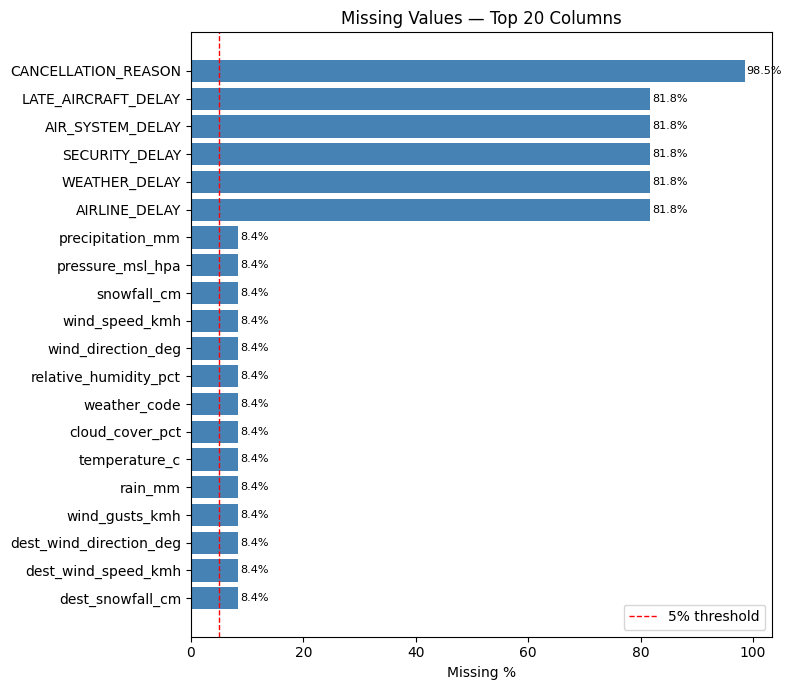

In [6]:
import matplotlib.pyplot as plt

missing = results['completeness']['details']['missing_report']
top = missing[missing['missing_count'] > 0].head(20)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(top.index[::-1], top['missing_pct'][::-1], color='steelblue', edgecolor='none')
ax.axvline(5, color='red', linestyle='--', linewidth=1, label='5% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values — Top 20 Columns')
ax.legend()
for bar, val in zip(bars, top['missing_pct'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 3. Duplicates

In [7]:
d = results['duplicates']['details']
print(f"Full-row duplicates    : {d['full_row_duplicates']}")
print(f"Flight-level duplicates: {d['flight_level_duplicates']} (codeshares — expected)")

Full-row duplicates    : 0
Flight-level duplicates: 864 (codeshares — expected)


## 4. Value Ranges

In [8]:
d = results['ranges']['details']
if d['range_violations']:
    pd.DataFrame(d['range_violations']).T
else:
    print('All values within expected ranges.')
print(f"\nNumeric origin airports (no IATA match) : {d['numeric_origin_airports']:,}")
print(f"Numeric dest airports (no IATA match)   : {d['numeric_dest_airports']:,}")

All values within expected ranges.

Numeric origin airports (no IATA match) : 9,723
Numeric dest airports (no IATA match)   : 9,723


## 5. Consistency

In [9]:
d = results['consistency']['details']
if d:
    for k, v in d.items():
        print(f"{k}: {v['count']} rows — {v['description']}")
else:
    print('All consistency checks passed.')

cancelled_but_has_departure_time: 97 rows — Cancelled flights that still have a DEPARTURE_TIME value.


## 6. Outlier Detection (IQR method)

In [10]:
outlier_rows = [
    {'column': col, **info}
    for col, info in results['outliers']['details'].items()
]
pd.DataFrame(outlier_rows).set_index('column')

,count,pct,lower_fence,upper_fence,min_outlier,max_outlier
column,,,,,,
DISTANCE,6939,5.96,-668.00,2108.00,2110.0,4983.0
SCHEDULED_TIME,5976,5.13,-46.00,306.00,307.0,718.0
ARRIVAL_DELAY,10200,8.93,-44.50,39.50,-79.0,1251.0
DEPARTURE_DELAY,14699,12.81,-23.00,25.00,-30.0,1250.0
TAXI_OUT,5627,4.91,-1.00,31.00,32.0,225.0
TAXI_IN,5665,4.95,-3.50,16.50,17.0,151.0
AIR_TIME,5993,5.24,-66.00,270.00,271.0,669.0
temperature_c,1061,1.00,-13.50,48.10,-32.4,-13.6
precipitation_mm,13913,13.06,0.00,0.00,0.1,15.5


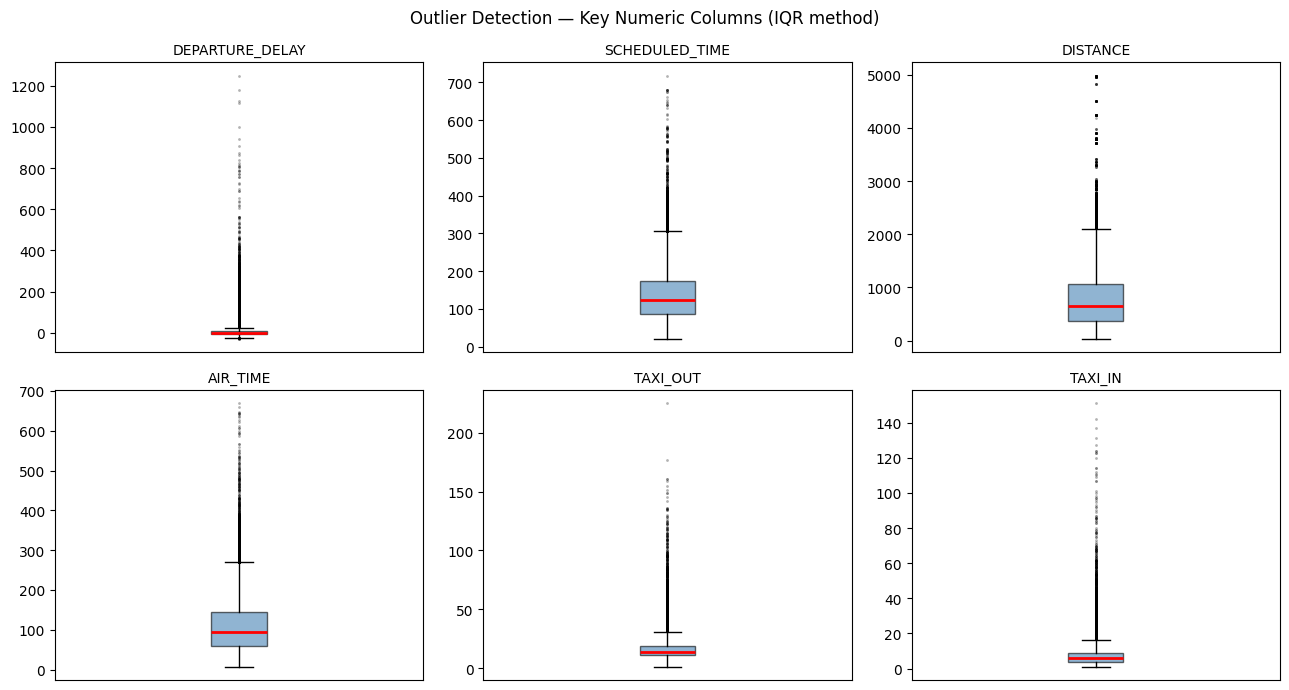

In [11]:
import matplotlib.pyplot as plt

outlier_cols = ['DEPARTURE_DELAY', 'SCHEDULED_TIME', 'DISTANCE', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN']
available = [c for c in outlier_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, available):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])
plt.suptitle('Outlier Detection — Key Numeric Columns (IQR method)', fontsize=12)
plt.tight_layout()
plt.show()


## 7. Format Validation

In [12]:
d = results['formats']['details']
if d:
    for k, v in d.items():
        print(f"{k}: {v['count']} rows — {v['description']}")
else:
    print('All format checks passed.')

All format checks passed.


## 8. Temporal Validity

In [13]:
d = results['temporal']['details']
if d['invalid_dates']:
    pd.DataFrame(d['invalid_dates'])
else:
    print('All dates are valid calendar dates.')

All dates are valid calendar dates.


## 9. Referential Integrity

In [14]:
d = results['referential_integrity']['details']
if d:
    for k, v in d.items():
        print(f"{k}: {v['count']} rows — {v['values'][:10]}")
else:
    print('All airline and airport codes match reference files.')

All airline and airport codes match reference files.


## 10. Cardinality

In [15]:
rows = [
    {'column': col, 'unique_count': info['unique_count'], 'top_values': list(info['top_5'].keys())}
    for col, info in results['cardinality']['details'].items()
]
pd.DataFrame(rows).set_index('column')

,unique_count,top_values
column,,
AIRLINE,14,"[WN, DL, AA, OO, EV]"
ORIGIN_AIRPORT,585,"[ATL, ORD, DFW, LAX, DEN]"
DESTINATION_AIRPORT,599,"[ATL, ORD, DFW, DEN, LAX]"
CANCELLATION_REASON,3,"[B, A, C]"
DAY_OF_WEEK,7,"[4, 5, 1, 3, 2]"
MONTH,12,"[7, 8, 3, 6, 5]"


## 11. Statistical Summary

In [16]:
results['statistics']['details']['stats']

,DISTANCE,SCHEDULED_TIME,ARRIVAL_DELAY,DEPARTURE_DELAY,TAXI_OUT,TAXI_IN,AIR_TIME,temperature_c,precipitation_mm,wind_speed_kmh,wind_gusts_kmh,cloud_cover_pct,relative_humidity_pct,pressure_msl_hpa,dest_temperature_c,dest_wind_speed_kmh
count,116381.00,116381.00,114271.00,114708.00,114633.00,114552.00,114271.00,106544.00,106544.00,106544.00,106544.00,106544.00,106544.00,106544.00,106558.00,106558.00
mean,824.73,141.95,4.42,9.32,16.08,7.45,113.80,16.64,0.11,10.77,25.47,54.62,64.66,1016.89,17.01,10.89
std,608.56,75.17,39.20,36.98,8.94,5.68,72.28,11.03,0.50,6.03,11.51,40.24,21.72,6.73,10.93,5.99
min,31.00,20.00,-79.00,-30.00,1.00,1.00,7.00,-32.40,0.00,0.00,1.80,0.00,3.00,968.50,-35.40,0.00
25%,373.00,86.00,-13.00,-5.00,11.00,4.00,60.00,9.60,0.00,6.40,16.90,10.00,50.00,1012.70,10.20,6.50
50%,651.00,123.00,-5.00,-2.00,14.00,6.00,95.00,18.50,0.00,9.70,23.80,60.00,67.00,1016.20,18.90,9.90
75%,1067.00,174.00,8.00,7.00,19.00,9.00,144.00,25.00,0.00,14.10,32.00,98.00,82.00,1020.70,25.20,14.20
max,4983.00,718.00,1251.00,1250.00,225.00,151.00,669.00,45.00,15.50,50.10,100.40,100.00,100.00,1056.90,45.30,48.10


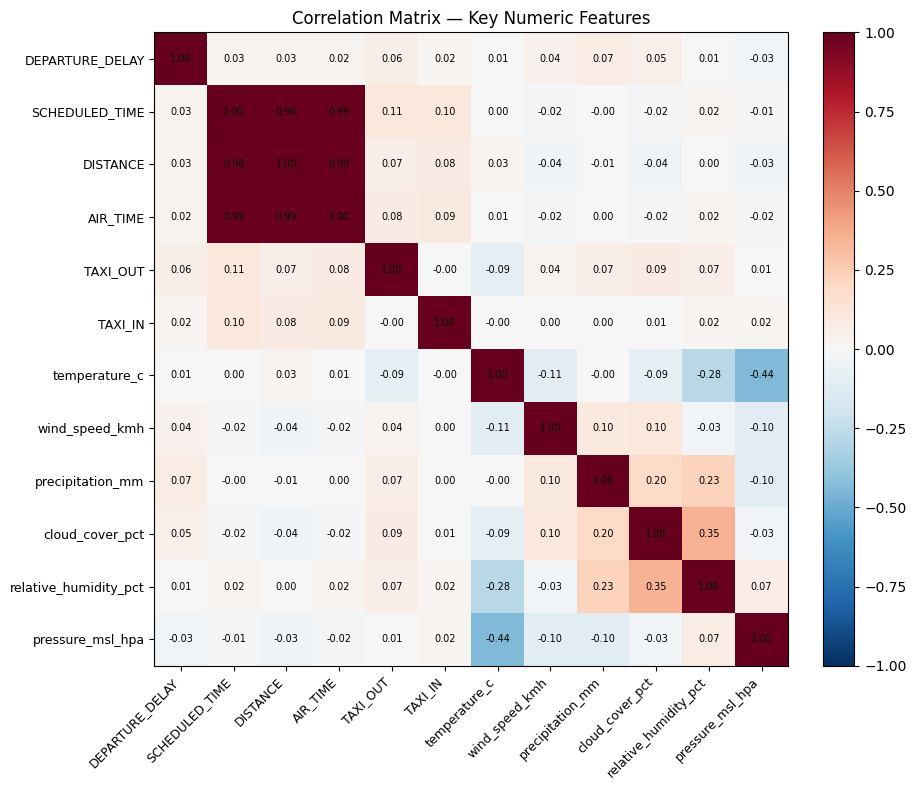

In [17]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = [
    'DEPARTURE_DELAY', 'SCHEDULED_TIME', 'DISTANCE', 'AIR_TIME',
    'TAXI_OUT', 'TAXI_IN', 'temperature_c', 'wind_speed_kmh',
    'precipitation_mm', 'cloud_cover_pct', 'relative_humidity_pct', 'pressure_msl_hpa'
]
available = [c for c in numeric_cols if c in df.columns]
corr = df[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(available)))
ax.set_yticks(range(len(available)))
ax.set_xticklabels(available, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(available, fontsize=9)
for i in range(len(available)):
    for j in range(len(available)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation Matrix — Key Numeric Features')
plt.tight_layout()
plt.show()


## 12. Target Variable Readiness

Total rows                           : 116,381
Cancelled flights                    : 1,770
DEPARTURE_DELAY nulls (non-cancelled): 0
Unlabellable rows                    : 0



,count,pct
class,,
on_time,94345,81.07
minor_delay,11433,9.82
major_delay,8833,7.59
cancelled,1770,1.52


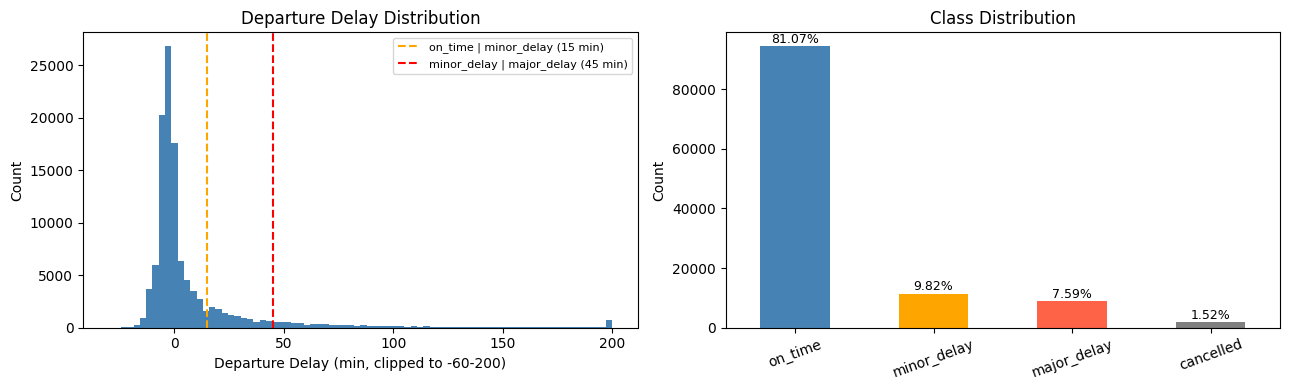

In [18]:
import matplotlib.pyplot as plt

d = results['target']['details']
print(f"Total rows                           : {d['total_rows']:,}")
print(f"Cancelled flights                    : {d['cancelled_count']:,}")
print(f"DEPARTURE_DELAY nulls (non-cancelled): {d['departure_delay_nulls']:,}")
print(f"Unlabellable rows                    : {d['unlabellable_rows']:,}")
print()

dist = pd.DataFrame([
    {'class': cls, 'count': cnt, 'pct': d['class_pct'][cls]}
    for cls, cnt in d['class_counts'].items()
]).set_index('class')
display(dist)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

delays = df.loc[df['CANCELLED'] == 0, 'DEPARTURE_DELAY'].dropna()
ax1.hist(delays.clip(-60, 200), bins=80, color='steelblue', edgecolor='none')
ax1.axvline(15, color='orange', linestyle='--', linewidth=1.5, label='on_time | minor_delay (15 min)')
ax1.axvline(45, color='red',    linestyle='--', linewidth=1.5, label='minor_delay | major_delay (45 min)')
ax1.set_xlabel('Departure Delay (min, clipped to -60-200)')
ax1.set_ylabel('Count')
ax1.set_title('Departure Delay Distribution')
ax1.legend(fontsize=8)

colors = ['steelblue', 'orange', 'tomato', 'grey']
dist['count'].plot.bar(ax=ax2, color=colors, edgecolor='none')
ax2.set_title('Class Distribution')
ax2.set_ylabel('Count')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=20)
for bar, pct in zip(ax2.patches, dist['pct']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
             f'{pct}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
